# DeepForest - ESA Stats Seminar - January 2025


The aim of this tutorial is to demonstrate the use of the DeepForest package for object detection in aerial imagery. We will work today to identify birds in drone images. DeepForest docs are here!

https://deepforest.readthedocs.io

1. Load a model
2. Split the orthomosaic into tiles
3. Predict on the tiles
4. Merge the predictions
5. Visualize the results
6. Split train-test
7. Evaluate the results

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import os
import sys
import comet_ml


## Load a model

DeepForest comes with several prebuilt models, for trees, birds, livestock, and other custom projects. We are open to creating and hosting more models based on the community needs.

In [11]:
from deepforest import main
import os
model = main.deepforest()
model.load_model(model_name="weecology/deepforest-bird", label_dict={"Bird": 0})



Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [12]:
## Do the same with DETR

# Download data


In [13]:
import requests
import zipfile
import io
import os
from pathlib import Path

deepwater_horizon_path = Path("data") /  "DeepWaterHorizon"

# Check if files already exist in data directory
if deepwater_horizon_path.exists():
    print(f"Files already downloaded to {deepwater_horizon_path.resolve()}:")
    for f in os.listdir("data"):
        print(f"- {f}")
else:

    # Download zip file from Dropbox
    url = "https://www.dropbox.com/scl/fo/p7mm97e9xo7a3gqtcs1cd/ANQ_YnFlOhkP-t7hc8At3_k?rlkey=c4eik22p4m1t1q4wct0cnk7ra&dl=1"
    response = requests.get(url)

    # Create data directory if it doesn't exist
    os.makedirs("data", exist_ok=True)

    # Extract zip contents
    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
        zip_ref.extractall("data")

    # Get list of extracted files
    files = os.listdir("data")

    print(f"Downloaded at {deepwater_horizon_path.resolve()} files:")
    for f in files:
        print(f"- {f}")


Files already downloaded to /home/cwinkelmann/work/deepforest/data/DeepWaterHorizon:
- DeepWaterHorizon
- michigan
- eikelboom_640
- iguana_floreana_640
- visualize


In [14]:
pwd

'/home/cwinkelmann/work/deepforest'

# Make initial predictions and view

We always think of DeepForest as the starting place for model development. The model is not intended to be used as a zero-shot tool. we expect that the model will be trained on a small dataset and then used to make predictions on a larger dataset.

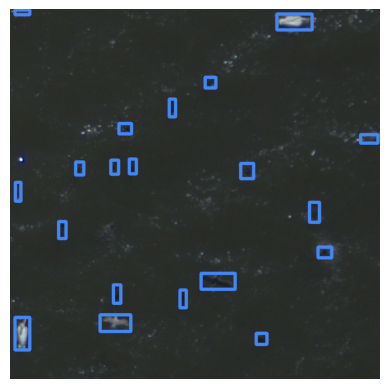

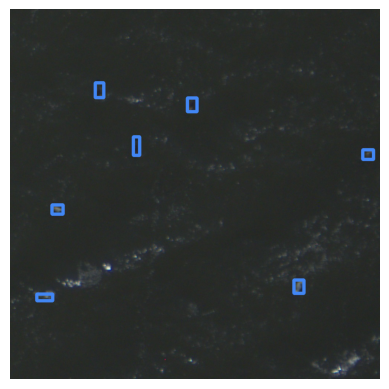

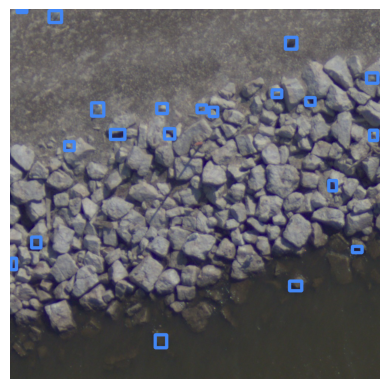

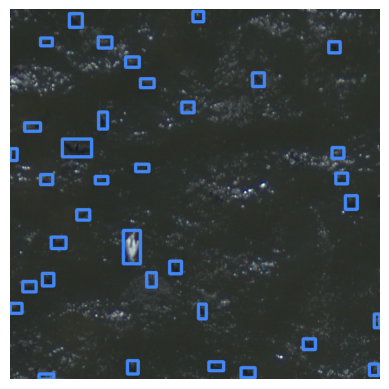

In [15]:
from deepforest import visualize
import glob
images = glob.glob("/home/cwinkelmann/work/deepforest/data/michigan/*.png")
visualize_dir = Path("data") / "visualize"
visualize_dir.mkdir(exist_ok=True)
zero_shot_predictions = []

# Make predictions on the first 4 images
for image in images[:4]:
    predictions = model.predict_image(path=image)
    zero_shot_predictions.append(predictions)
    visualize.plot_results(predictions, thickness=7, savedir=visualize_dir)
    visualize.plot_results(predictions, thickness=7)



These images show adequate results, but can be improved with local annotations

## Annotate data in target imagery

We use label-studio to annotate data in target imagery. Data can be exported as pascal voc or COCO format.

![image.png](attachment:image.png)

## Load annotations
The deepforest.utilities.read_file function can load csv, shapefiles, or xml formats.

In [17]:
from deepforest.utilities import read_file
from deepforest import visualize


annotations = read_file("/home/cwinkelmann/work/deepforest/data/michigan/michigan_test.csv")
annotations.head()

,unnamed: 0.1,unnamed: 0,xmin,ymin,xmax,ymax,image_path,label,geometry
0,0,0,386.2944,798.2550,463.151,885.3370,C1_L9_F490_T20200925_132209_363_4.png,Bird,"POLYGON ((463.151 798.255, 463.151 885.337, 38..."
1,0,0,386.2944,746.2550,463.151,833.3370,C1_L9_F490_T20200925_132209_363_5.png,Bird,"POLYGON ((463.151 746.255, 463.151 833.337, 38..."
2,1,1,683.3030,775.0318,749.035,854.6612,C1_L9_F490_T20200925_132209_363_6.png,Bird,"POLYGON ((749.035 775.032, 749.035 854.661, 68..."
3,7,7,902.6270,625.7950,980.358,707.0290,C2_L7_F288_T20200925_131723_433_8.png,Bird,"POLYGON ((980.358 625.795, 980.358 707.029, 90..."
4,4,4,127.9720,526.3400,202.963,613.5580,C2_L7_F288_T20200925_131723_433_14.png,Bird,"POLYGON ((202.963 526.34, 202.963 613.558, 127..."


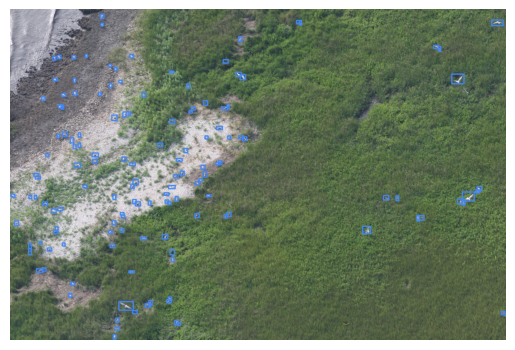

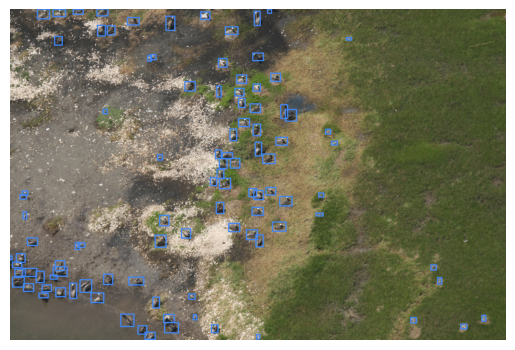

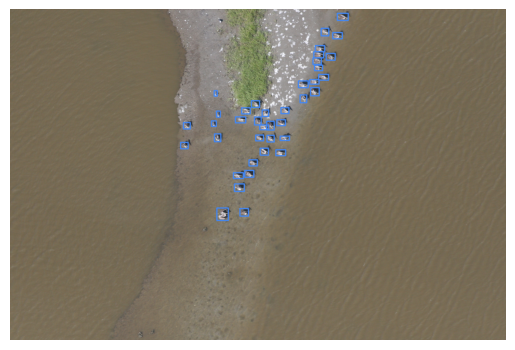

In [12]:


# plot a couple images with annotations
image = "data/DeepWaterHorizon/20240715_140000_0000_RGB.tif"
image_annotations = annotations[annotations.image_path == annotations.image_path.unique()[0]]
image_annotations.root_dir = "data/DeepWaterHorizon"
visualize.plot_results(image_annotations, thickness=7)

image_annotations = annotations[annotations.image_path == annotations.image_path.unique()[1]]
image_annotations.root_dir = "data/DeepWaterHorizon"
visualize.plot_results(image_annotations, thickness=7)

image_annotations = annotations[annotations.image_path == annotations.image_path.unique()[2]]
image_annotations.root_dir = "data/DeepWaterHorizon"
visualize.plot_results(image_annotations, thickness=7 )


###  Fine-tune example

The key parameter is the learning rate. Faster learning rates make the model learn more quickly, but also cause it to forgot more of that it already knew. Its best to test a few tries carefully. A default around 0.0001 is often a good guess.

In [17]:
os.getenv("COMET_API_KEY")

In [ ]:
%timeit

# Comment out if comet-ml is not installed
import comet_ml
from pytorch_lightning.loggers import CometLogger
comet_logger = CometLogger(api_key="bVOa3vnaXoP7OIstSDdblokzb")

# Just reload here to make sure we are starting from the same model
model = main.deepforest()

model.load_model(model_name="weecology/deepforest-bird", label_dict = {"Bird": 0})



model.config["train"]["csv_file"] = "/home/cwinkelmann/work/deepforest/data/michigan/michigan_train.csv"
model.config["train"]["root_dir"] = "/home/cwinkelmann/work/deepforest/data/michigan/"
model.config["validation"]["csv_file"] = "/home/cwinkelmann/work/deepforest/data/michigan/michigan_test.csv"
model.config["validation"]["root_dir"] = "/home/cwinkelmann/work/deepforest/data/michigan/"
model.config["validation"]["val_accuracy_interval"] = 2
model.config["train"]["epochs"] = 30
model.config["train"]["lr"] = 0.00001
model.config["batch_size"] = 15

# Train model for just a few steps for show on cpu (model.create_trainer(max_steps=5)), takes 1 min on GPU
model.create_trainer(logger=comet_logger)
model.trainer.fit(model)



COMET INFO: An experiment with the same configuration options is already running and will be reused.
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Trainer already configured with model summary 

Epoch 0: 100%|██████████| 324/324 [04:15<00:00,  1.27it/s, v_num=6ae3]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|██████████| 44/44 [00:40<00:00,  1.07it/s]


Epoch 1: 100%|██████████| 324/324 [04:11<00:00,  1.29it/s, v_num=6ae3]  
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 324/324 [04:11<00:00,  1.29it/s, v_num=6ae3]  
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|██████████| 44/44 [00:40<00:00,  1.09it/s]


Epoch 3: 100%|██████████| 324/324 [04:12<00:00,  1.28it/s, v_num=6ae3]  
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 324/324 [04:11<00:00,  1.29it/s, v_num=6ae3]  
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|██████████| 44/44 [00:40<00:00,  1.09it/s]


Epoch 5: 100%|██████████| 324/324 [04:10<00:00,  1.29it/s, v_num=6ae3]  
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 6: 100%|██████████| 324/324 [04:08<00:00,  1.30it/s, v_num=6ae3]  
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|██████████| 44/44 [00:40<00:00,  1.09it/s]

...


Epoch 13: 100%|██████████| 324/324 [04:10<00:00,  1.29it/s, v_num=6ae3] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 14: 100%|██████████| 324/324 [04:11<00:00,  1.29it/s, v_num=6ae3] 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|██████████| 44/44 [00:40<00:00,  1.08it/s]


Epoch 15: 100%|██████████| 324/324 [04:11<00:00,  1.29it/s, v_num=6ae3] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 16: 100%|██████████| 324/324 [04:10<00:00,  1.29it/s, v_num=6ae3] 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|██████████| 44/44 [00:40<00:00,  1.09it/s]


Epoch 17: 100%|██████████| 324/324 [04:11<00:00,  1.29it/s, v_num=6ae3] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 18: 100%|██████████| 324/324 [04:10<00:00,  1.30it/s, v_num=6ae3] 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|██████████| 44/44 [00:40<00:00,  1.08it/s]


Epoch 19: 100%|██████████| 324/324 [04:11<00:00,  1.29it/s, v_num=6ae3] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 20: 100%|██████████| 324/324 [04:10<00:00,  1.29it/s, v_num=6ae3] 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|██████████| 44/44 [00:40<00:00,  1.09it/s]


Epoch 21:   1%|          | 2/324 [00:01<04:03,  1.32it/s, v_num=6ae3]   

In [20]:
test_annotations

,xmin,ymin,xmax,ymax,label,image_path,annotator,geometry
0,638.102643,36.427119,663.224794,67.829809,Bird,avian_monitoring_high_resolution_photos_2010_B...,"sanacleto@ufl.edu, 24","POLYGON ((663.225 36.427, 663.225 67.83, 638.1..."
1,643.127073,100.488605,660.712579,120.586326,Bird,avian_monitoring_high_resolution_photos_2010_B...,"sanacleto@ufl.edu, 24","POLYGON ((660.713 100.489, 660.713 120.586, 64..."
2,301.465816,336.636827,324.075752,361.758979,Bird,avian_monitoring_high_resolution_photos_2010_B...,"sanacleto@ufl.edu, 24","POLYGON ((324.076 336.637, 324.076 361.759, 30..."
3,336.636827,326.587967,360.502871,351.710118,Bird,avian_monitoring_high_resolution_photos_2010_B...,"sanacleto@ufl.edu, 24","POLYGON ((360.503 326.588, 360.503 351.71, 336..."
4,438.381540,329.100182,463.503691,352.966226,Bird,avian_monitoring_high_resolution_photos_2010_B...,"sanacleto@ufl.edu, 24","POLYGON ((463.504 329.1, 463.504 352.966, 438...."
...,...,...,...,...,...,...,...,...
287,2056.269290,2194.192005,2091.076707,2234.800658,Bird,avian_monitoring_high_resolution_photos_2010_B...,"sanacleto@ufl.edu, 24","POLYGON ((2091.077 2194.192, 2091.077 2234.801..."
288,2034.353509,2225.776513,2076.895907,2267.029748,Bird,avian_monitoring_high_resolution_photos_2010_B...,"sanacleto@ufl.edu, 24","POLYGON ((2076.896 2225.777, 2076.896 2267.03,..."
289,2116.859979,2236.089822,2172.938595,2266.385166,Bird,avian_monitoring_high_resolution_photos_2010_B...,"sanacleto@ufl.edu, 24","POLYGON ((2172.939 2236.09, 2172.939 2266.385,..."
290,2158.113213,2287.656365,2188.408558,2328.909600,Bird,avian_monitoring_high_resolution_photos_2010_B...,"sanacleto@ufl.edu, 24","POLYGON ((2188.409 2287.656, 2188.409 2328.91,..."


In [1]:
import numpy as np
fine_tuned_predictions = []
for image in test_images:
    relative_path = os.path.join("data/DeepWaterHorizon", image)
    # predictions = model.predict_image(path=relative_path)
    predictions = model.predict_tile(path=relative_path)

    print(f"average score: {np.mean([s for s in predictions.score])}")
    filtered_predictions = predictions[predictions["score"] > -2.0]
    filtered_predictions.root_dir = predictions.root_dir

    #
    print(filtered_predictions)


    if len(filtered_predictions) == 0:
        print(f"predictions: {filtered_predictions}")
        continue
    else:
        fine_tuned_predictions.append(filtered_predictions)
        # visualize.plot_results(predictions, ground_truth=test_annotations, thickness=7)
        visualize.plot_results(filtered_predictions, thickness=7)

NameError: name 'test_images' is not defined

In [19]:
import torch
root_folder = "data/DeepWaterHorizon/models"
# Save the model checkpoint
model.trainer.save_checkpoint(
    os.path.join(root_folder, "checkpoint_epochs_10_cosine_lr_retinanet.pl"))
torch.save(model.model.state_dict(), os.path.join(root_folder, "weights_cosine_lr"))
# Load from the saved checkpoint


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..


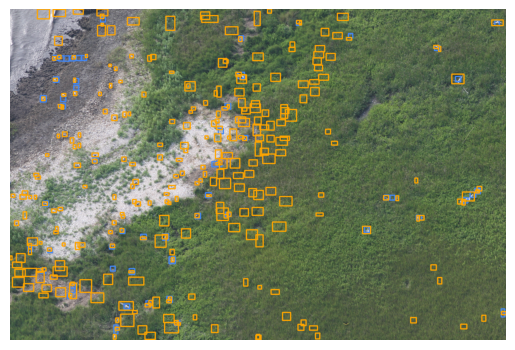

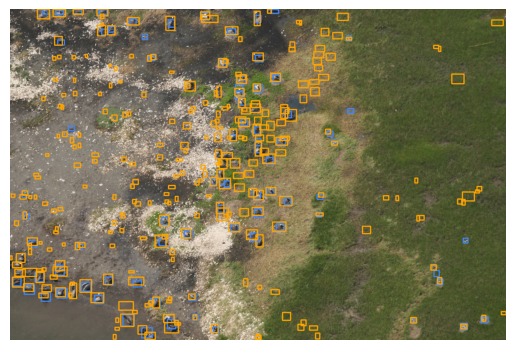

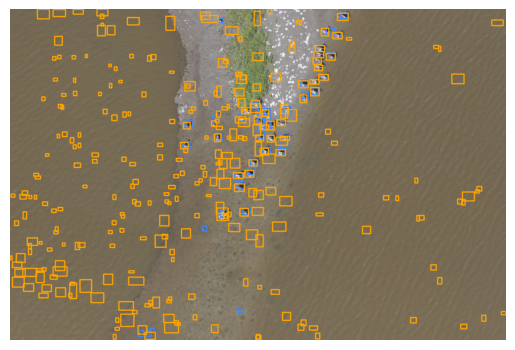

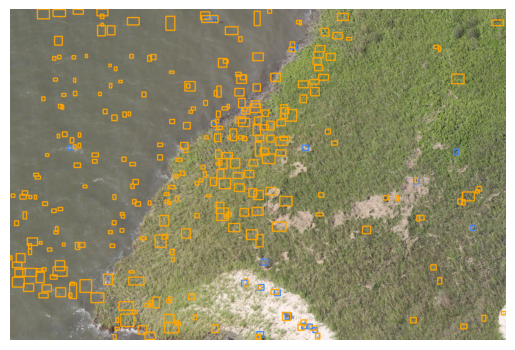

In [20]:
loaded_model = main.deepforest.load_from_checkpoint(
    os.path.join(root_folder, "checkpoint_epochs_10_cosine_lr_retinanet.pl"))
# Add a path to an image to test the model on
fine_tuned_predictions = []
for image in test_images:
    relative_path = os.path.join("data/DeepWaterHorizon", image)
    predictions = loaded_model.predict_image(path=relative_path)
    fine_tuned_predictions.append(predictions)
    visualize.plot_results(predictions, ground_truth=test_annotations, thickness=7)

In [21]:
# Evaluate on test set
results = model.evaluate(
    csv_file='data/DeepWaterHorizon/test_annotations.csv',
    root_dir='data/DeepWaterHorizon',
)
print(f"box precision: {results['box_precision']} and recall: {results['box_recall']}")
# save the results to a csv file
results["results"].to_csv("results_test_lr_cosine.csv", index=False)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 10.46it/s]


box precision: 0.2952968686334537 and recall: 0.4017140468227425


In [25]:
comet_logger.experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : alone_aggregate_2849
COMET INFO:     url                   : https://www.comet.com/karisu/general/67d2304c0e154e9cb879d78809c7ffb6
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     Bird_Precision                  : 1.0
COMET INFO:     Bird_Recall                     : 1.0
COMET INFO:     box_precision [2]               : (0.21139052510261536, 0.2424469143152237)
COMET INFO:     box_recall [2]                  : (0.2654905319213867, 0.31290969252586365)
COMET INFO:     iou [2]                         : (0.5207956433296204, 0.5612814426422119)
COMET INFO:     iou/cl_0 [2]                    : (0.5207956433296204, 0.5612814426422119)
COMET INFO:

# How many annotations do we need?

Let's write a loop to split the train test data, fit the model, and evaluate the results.


In [29]:
train_annotations

,xmin,ymin,xmax,ymax,label,image_path,annotator,geometry
292,194.985993,343.884387,226.183752,371.536946,Bird,avian_monitoring_high_resolution_photos_2010_B...,"sanacleto@ufl.edu, 24","POLYGON ((226.184 343.884, 226.184 371.537, 19..."
293,534.616140,379.336386,565.813899,409.825105,Bird,avian_monitoring_high_resolution_photos_2010_B...,"sanacleto@ufl.edu, 24","POLYGON ((565.814 379.336, 565.814 409.825, 53..."
294,757.254692,220.511432,791.997651,250.291111,Bird,avian_monitoring_high_resolution_photos_2010_B...,"sanacleto@ufl.edu, 24","POLYGON ((791.998 220.511, 791.998 250.291, 75..."
295,690.604934,303.469109,757.254692,331.830708,Bird,avian_monitoring_high_resolution_photos_2010_B...,"sanacleto@ufl.edu, 24","POLYGON ((757.255 303.469, 757.255 331.831, 69..."
296,1096.530325,494.345498,1127.457543,505.624836,Bird,avian_monitoring_high_resolution_photos_2010_B...,"sanacleto@ufl.edu, 24","POLYGON ((1127.458 494.345, 1127.458 505.625, ..."
...,...,...,...,...,...,...,...,...
10627,2051.961439,1745.731255,2089.540558,1764.875335,Bird,avian_monitoring_high_resolution_photos_2010_B...,"sanacleto@ufl.edu, 24","POLYGON ((2089.541 1745.731, 2089.541 1764.875..."
10628,859.176550,1622.530468,878.320629,1650.892067,Bird,avian_monitoring_high_resolution_photos_2010_B...,"sanacleto@ufl.edu, 24","POLYGON ((878.321 1622.53, 878.321 1650.892, 8..."
10629,915.899748,1348.131999,946.388467,1376.493598,Bird,avian_monitoring_high_resolution_photos_2010_B...,"sanacleto@ufl.edu, 24","POLYGON ((946.388 1348.132, 946.388 1376.494, ..."
10630,162.321939,773.175492,182.140316,813.755977,Bird,avian_monitoring_high_resolution_photos_2010_B...,"sanacleto@ufl.edu, 24","POLYGON ((182.14 773.175, 182.14 813.756, 162...."


In [28]:

import pandas as pd
import matplotlib.pyplot as plt

# Silence warnings and stdout
#import warnings
#warnings.filterwarnings("ignore")

# Get unique image names

results = []

train_fractions = [0, 0.05, 0.1, 0.5, 0.9]
for fraction in train_fractions:
    model = main.deepforest()
    model.load_model("Weecology/DeepForest-bird")
    if not fraction == 0:
        train_images = train_annotations['image_path'].sample(frac=fraction, random_state=1).tolist()
        filtered_train = train_annotations[train_annotations['image_path'].isin(train_images)].copy(deep=True)

        print(f"filtered_train: {filtered_train}")

        # Save temporary CSV files
        filtered_train.to_csv('data/temp_train.csv', index=False)

        # Configure model
        model.config["train"]["csv_file"] = 'data/temp_train.csv'
        model.config["train"]["root_dir"] = "data/DeepWaterHorizon"
        model.config["train"]["epochs"] = 20
        model.config["train"]["lr"] = 0.00001

        model.config["validation"]["csv_file"] = "data/DeepWaterHorizon/test_annotations.csv"
        model.config["validation"]["root_dir"] = "data/DeepWaterHorizon"
        model.config["validation"]["val_accuracy_interval"] = 2

        model.config["batch_size"] = 15


        # Train model
        model.create_trainer()
        model.trainer.fit(model)

        comet_logger.experiment.end()

    # Evaluate on test set
    results_dict = model.evaluate(
        csv_file=deepwater_horizon_path / "test_annotations.csv",
        root_dir=deepwater_horizon_path,
    )

    results.append({
        'train_fraction': fraction,
        'precision': results_dict['box_precision'],
        'recall': results_dict['box_recall'],
    })

    comet_logger.experiment.end()

    # Plot results
results_df = pd.DataFrame(results)

print(results_df)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a def

ValueError: Input must be a path to a file, geopandas or a pandas dataframe

In [ ]:
results_df = pd.DataFrame(results)
plt.figure(figsize=(6, 4))
plt.plot(results_df['train_fraction'], results_df['precision'], 'o-', label='Precision')
plt.plot(results_df['train_fraction'], results_df['recall'], 'o-', label='Recall')
plt.xlabel('Training Set Fraction')
plt.ylabel('Score')
plt.title('Model Performance vs Training Set Size')
plt.legend()
plt.grid(True)
plt.show()

## Optional split orthomosaic into tiles

Often we have images that are too large to run into training. DeepForest has tools to split them into pieces.
The key aspect is the patch size and overlap. The patch size can have an effect on model performance. It is important to try different patch sizes and overlaps to find the best performance. This is an area of active research.
This function can take in annotations and return only the crops that have overlapping annotations, or it can be used to split the image into crops without annotations. Use allow_empty=False to return only the crops that have overlapping annotations.

In [ ]:
from deepforest.preprocess import split_raster
import os
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show

image_path = "data/DeepWaterHorizon/East_Pita_Yearly_2024-2-1.tif"
output_dir = "data/crops"
os.makedirs(output_dir, exist_ok=True)

# In this case we have no annotations, but in other cases we could use them to split the image into crops, only keeping rames with annotations, allow_empty=False.
crop_annotations = split_raster(
    path_to_raster=image_path,
    annotations_file=None,
    base_dir=output_dir,
    patch_size=2000,
    patch_overlap=0,
    allow_empty=True
)

# Plot a few crops
for crop in crop_annotations[:5]:
    # Read the crop
    crop_image = rasterio.open(crop).read([1,2,3])
    show(crop_image)

We can combine the steps and cut into pieces, predict on pieces and mosaic the pieces back together. In addition, we can perform overlapping box suppression to avoid double counting on edges.

In [ ]:
# Read ortho using rasterio drop alpha channel, transpose to channels first
from deepforest import utilities
from shapely import geometry
raster = rasterio.open(image_path).read([1,2,3])
channels_first = raster.transpose(1, 2, 0)
orthomosaic_predition = model.predict_tile(image=channels_first, patch_size=2000, patch_overlap=0)
orthomosaic_predition["image_path"] = os.path.basename(image_path)

# Export as a shapefile
geo_coords = utilities.image_to_geo_coordinates(orthomosaic_predition, root_dir=os.path.dirname(image_path))
print(geo_coords.head())
geo_coords.to_file("data/DeepWaterHorizon/orthomosaic_predictions.shp")

# The future of DeepForest

DeepForest was originally written as a single reproducible eample for a paper in 2018. It never occured to us that we would be designing a general airborne object detection package. However, the demand in the community, the constant requests for help, and the general need in the space has led us to develop a more general package. We are aiming for DeepForest 2.0 by next year that will have point, polygon and box support, robust classficiation and two-stage workflows and several new biodiversity models. We welcome feedback on the DeepForest github repo about your needs and ideas.

DeepForest needs your help! We are looking for people to help with the development of the package. If you are interested in contributing to the project, please contact us on the github repo. Submit issues for everything, no item is too small to be improved. The docs, the naming of functions, everything can be simpler and we want to hear from you.